# Discrete Fourier transform

In the cell below, we created a sinusoidal function:

$$f(x) = A_1 \sin\bigg(\frac{2\pi}{L}n_1 x\bigg) + A_2 \sin \bigg( \frac{2\pi}{L}n_2 x \bigg),$$ 

which contains a low frequency and a high frequency components.

The 1st derivative is 

$$f'(x) = A_1 \frac{2\pi}{L}n_1\cos\bigg(\frac{2\pi}{L}n_1 x\bigg) + A_2 \frac{2\pi}{L}n_2 \cos\bigg( \frac{2\pi}{L}n_2 x \bigg),$$

The 2nd derivative is

$$f''(x) = -A_1 \bigg(\frac{2\pi}{L}n_1 \bigg)^2\sin\bigg(\frac{2\pi}{L}n_1 x\bigg) - A_2 \bigg(\frac{2\pi}{L}n_2 \bigg)^2\sin\bigg( \frac{2\pi}{L}n_2 x \bigg).$$

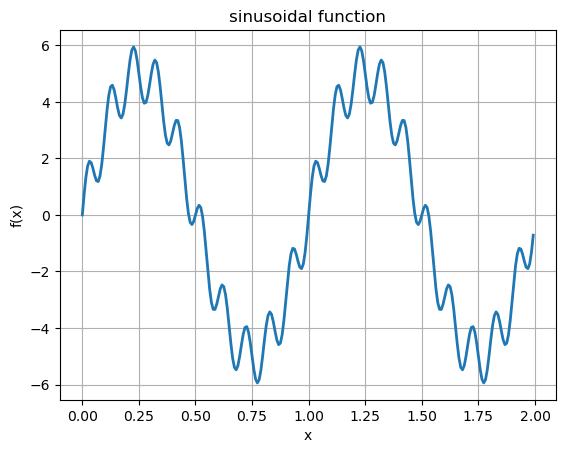

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# define domain and discretization
# -----------------------------
L = 2.0
gpt = 256

# x in [0, L), 256 points
x = np.linspace(0.0, L, gpt, endpoint=False)

# -----------------------------
# sinusoidal function
# -----------------------------
A1 = 5.0
A2 = 1.0
n1 = 2.0
n2 = 20.0

f1 = A1 * np.sin(2.0 * np.pi / L * n1 * x)
f2 = A2 * np.sin(2.0 * np.pi / L * n2 * x)

f = f1 + f2

# -----------------------------
# visualize the wave function
# -----------------------------
plt.plot(x, f, '-', linewidth=2)
plt.title('sinusoidal function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show(block=False)


---
## Using discrete Fourier transform to calculate derivatives.

$F(f(x))$ is the Fourier transform of $f(x)$. The Fourier transform of $f'(x)$ is 

$$F(f'(x)) = i \omega F(f(x)),$$

which is just multiplying $F(f(x))$ with $i \omega$.
We can calculate 1st derivative by taking inverse Fourier transform of $F(f'(x))$: 

$$f'(x) = F^{-1} \big[F(f'(x)) \big] = F^{-1}\big[ i \omega F(f(x)) \big].$$

### Note of wave number, reciprocal vector, and frequency in FFT.

The cell below sets up reciprocal vectors ($\omega$). Note that `fft` function is written for signal processing (time series analysis), its frequency (equivalent to wave number in space) is ordered from 0 to $2\pi$. (Frequency is the wave number in time, which does not have negative values.) However, when we use reciporal coordinate (which is the spatial coodinate in the reciprocal space), the wave number goes from $-\pi$ to $\pi$. Thus, in order to use `fft` function, we must re-arrange the wave number to be in the same ordering as in signal processing, which can be done using a common `fftshift` function.

In the discrete Fourier transform, the number of coordinate points in the Fourier space is the same as the number of discrete values in the real space. Thus, for a $N$ point data in the real space, the discrete reciporal basis (coordinate in the Fourier space or wave number) is 

$$\omega_i = [-N/2-1, -N/2, -N/2+1, ..., -2, -1, 0, 1, 2, ..., N/2-1, N/2]\times \frac{2\pi}{L},$$

corresponding to the range of $[-\pi, \pi]$.
Then, we perform Fourier shift such that we can use the `fft` function designed for discrete Fourier transform of time series data (frequency goes from 0 to $2\pi$, i.e.,)

$$\omega = [0, 1, 2, ..., N/2-1, N/2, -N/2-1, -N/2, -N/2+1, ..., -2, -1, ]\times \frac{2\pi}{L}.$$

The code cell below demostrates the use of `fftshift`.

Text(0, 0.5, '($\\omega$, $\\mu$)')

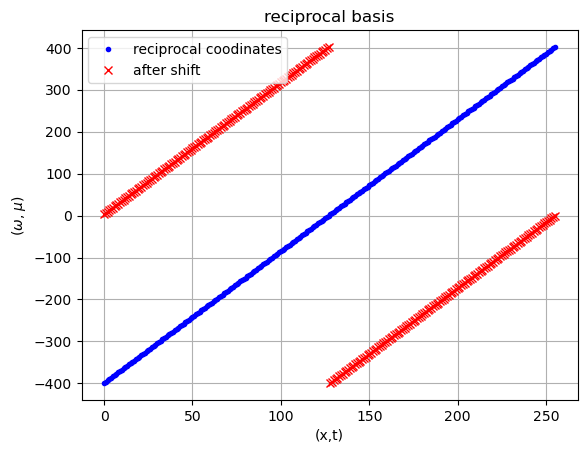

In [75]:
import matplotlib.pyplot as plt

# number of sampling points
N = gpt

# reciprocal basis
w1 = np.arange(-(N//2 - 1), N//2 + 1) * 2.0 * np.pi / L   # length N
# N//2 returns an integer (floor) of N/2

# using FFT shift
w = np.fft.fftshift(w1)

plt.plot(w1,'b.',label='reciprocal coodinates')
plt.grid()
plt.title('reciprocal basis')
plt.plot(w,'rx',label='after shift')
plt.legend()
plt.xlabel('(x,t)')
plt.ylabel(r'($\omega$, $\mu$)')

---
## First derivative

We will use the code cell below to 

* Plot the 1st derivative of the sinusoidal function above.
* Use discrete Fourier transform to calculate the 1st derivative of a sinusoidal function.
* Use `np.fft` function for discrete Fourier transform and `np.ifft` for discrete inverse Fourier transform.

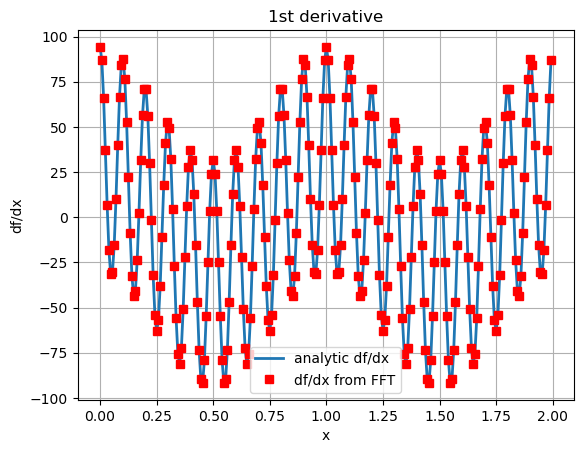

In [19]:
# -----------------------------
# first derivative (analytic)
# -----------------------------
df = (A1 * (2.0 * np.pi / L * n1) * np.cos(2.0 * np.pi / L * n1 * x)
    + A2 * (2.0 * np.pi / L * n2) * np.cos(2.0 * np.pi / L * n2 * x))

# visualize the 1st derivative
plt.plot(x, df, linewidth=2, label='analytic df/dx')


# -----------------------------
# FFT of f
# -----------------------------
Ft = np.fft.fft(f)

# -----------------------------
# 1st derivative in Fourier space
# -----------------------------
dFt = 1j * w * Ft

# inverse FFT -> numerical 1st derivative in real space
ndf = np.fft.ifft(dFt)

# visualize the obtained 1st derivative
plt.plot(x, np.real(ndf), 'rs', linewidth=2, label='df/dx from FFT')
plt.legend()
plt.title('1st derivative')
plt.xlabel('x')
plt.ylabel('df/dx')
plt.grid(True)
plt.show(block=False)

---
## Second derivative

We can take Fourier transform of $f''(x)$ as

$$F(f''(x)) = i \omega F( f'(x)) = i \omega F \{ F^{-1}[ i \omega F(f(x))] \} = - \omega^2 F(f(x)),$$

which is simply the mulitplication of $\omega^2$ and $F(f(x))$. No derivative has been calculated explicitly. From that, the 2nd derivatives can be obtained by 

$$f''(x) = F^{-1} [ - \omega^2 F(f(x))]. $$

The cell below demonstrates calculating a 2nd derivative using Fourier transform.

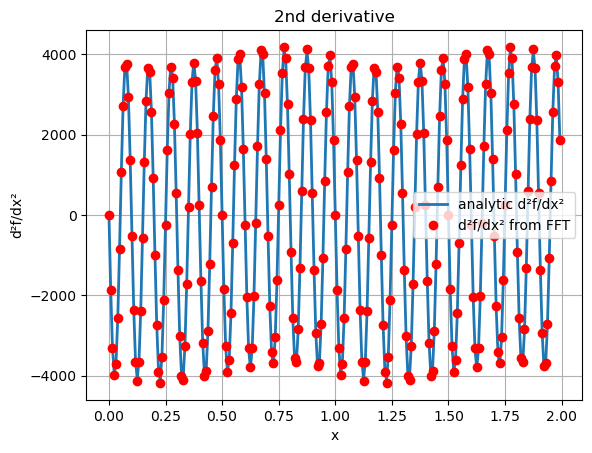

In [21]:
# -----------------------------
# 2nd derivative (analytic)
# -----------------------------
ddf = (-A1 * (2.0 * np.pi / L * n1) ** 2 * np.sin(2.0 * np.pi / L * n1 * x)
    -A2 * (2.0 * np.pi / L * n2) ** 2 * np.sin(2.0 * np.pi / L * n2 * x))

# visualize the 2nd derivative
plt.plot(x, ddf, linewidth=2, label='analytic d²f/dx²')

# -----------------------------
# 2nd derivative in Fourier space
# -----------------------------
ddFt = -(w * w) * Ft

# inverse FFT -> numerical 2nd derivative in real space
nddf = np.fft.ifft(ddFt)

# visualize the obtained 2nd derivative
plt.plot(x, np.real(nddf), 'ro', label='d²f/dx² from FFT')
plt.legend()
plt.title('2nd derivative')
plt.xlabel('x')
plt.ylabel('d²f/dx²')
plt.grid(True)
plt.show(block=False)



We can see that derivatives can be efficiently calculated using FFT without using finite difference method that computes derivative in the real space.